# Gas and Ridership Visualization

In [7]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
# Reads fuel price data
gas_weekly = pd.read_csv("../../data/02-processed/nyc_gas_prices_weekly_2023.csv")
# Reads ridership data
ridership_weekly = pd.read_csv("../../data/01-interim/MTA_subway/MTA_Subway_Weekly_Manhattan_Totals.csv")
# Turn datasets into dataframe
ridership_df['date'] = pd.to_datetime(ridership_df['date'])
gas_df['date'] = pd.to_datetime(gas_df['date'])
# Make it the same week
ridership_df['week'] = ridership_df['date'] - pd.to_timedelta(ridership_df['date'].dt.dayofweek, unit='D')
gas_df['week'] = gas_df['date'] - pd.to_timedelta(gas_df['date'].dt.dayofweek, unit='D')
# Merge
df = pd.merge(ridership_df, gas_df, on='week', how='inner')
df = df.rename(columns={
    "ridership_y": "gas_price",
    "ridership_x": "ridership"
})
df.head()

# gas_df = pd.DataFrame(gas_weekly)
# ridership_df = pd.DataFrame(ridership_weekly)
# gas_df.columns = ridership_df.columns.str.lower()
# # Merge data
# df = pd.merge(ridership_df, gas_df, on="date", how="inner")
# df = df.rename(columns={
#     "total_weekly_trips_y": "gas_price",
#     "total_weekly_trips_x": "ridership"
# })
# df.head()

,date_x,ridership,week,date_y,gas_price
0,2023-01-08,10290807,2023-01-02,2023-01-02,3.247
1,2023-01-15,11188333,2023-01-09,2023-01-09,3.231
2,2023-01-22,10738820,2023-01-16,2023-01-16,3.259
3,2023-01-29,11498691,2023-01-23,2023-01-23,3.367
4,2023-02-05,11294077,2023-01-30,2023-01-30,3.428


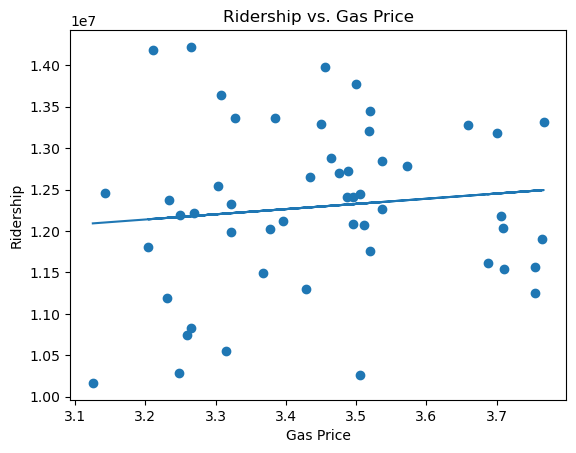

In [13]:
m, b = np.polyfit(df['gas_price'], df['ridership'], 1)
plt.scatter(df['gas_price'], df['ridership'])
plt.plot(df['gas_price'], m*df['gas_price'] + b)
plt.xlabel("Gas Price")
plt.ylabel("Ridership")
plt.title('Ridership vs. Gas Price')
plt.savefig('ridership_gas_price_scatter_plot.png')
plt.show()

In [14]:
# Correlation Factor
print(round(df['gas_price'].corr(df['ridership']), 3))

0.11


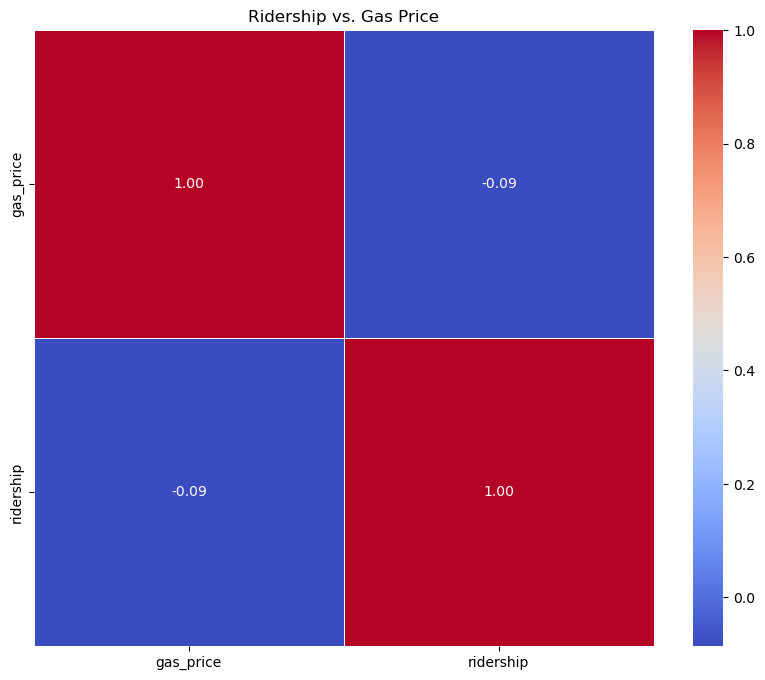

In [6]:
# Correlation Matrix
corr_matrix = df[['gas_price', 'ridership']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ridership vs. Gas Price')
plt.savefig('ridership_gas_price_correlation.png')
plt.show()